In [28]:
import numpy as np
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [29]:
# load data and autoencoder
X = np.load('../data/processed/X.npy')
autoencoder = keras.models.load_model("../models/AEs/autoencoder_full_conv.keras")
encoder = keras.models.load_model("../models/AEs/encoder_only_conv.keras")

In [30]:
# extract latent representations
Z = encoder.predict(X, batch_size=64)
np.save('../data/processed/Z_256.npy', Z)
Z.shape

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


(9565, 256)

<function matplotlib.pyplot.show(close=None, block=None)>

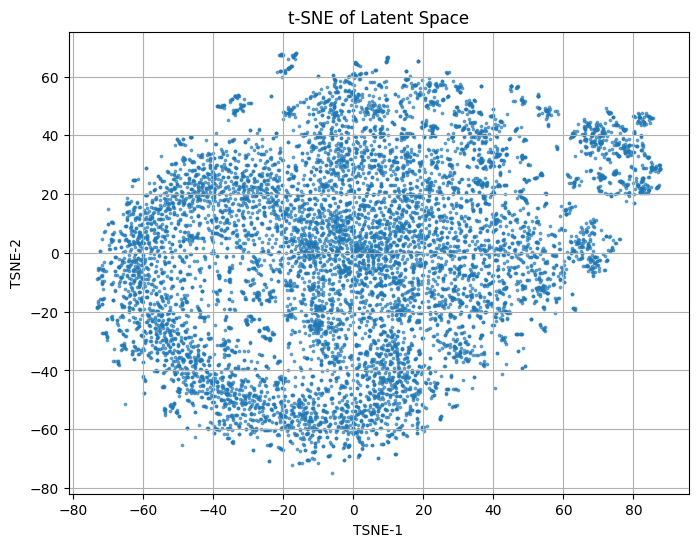

In [31]:
# tsne visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
Z_2D = tsne.fit_transform(Z)

plt.figure(figsize=(8,6))
plt.scatter(Z_2D[:, 0], Z_2D[:, 1], s=3, alpha=0.6)
plt.title('t-SNE of Latent Space')
plt.xlabel('TSNE-1')
plt.ylabel('TSNE-2')
plt.grid(True)
plt.show

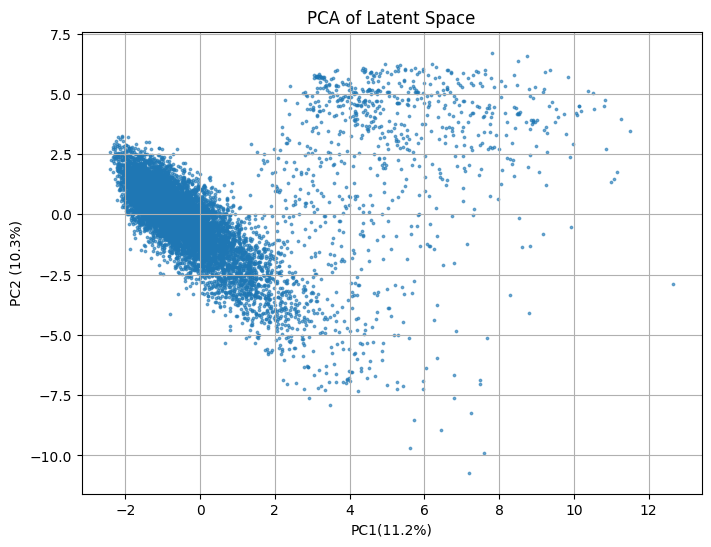

In [32]:
# PCA visualization
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z)

# plot PCA scatter
plt.figure(figsize=(8, 6))
plt.scatter(Z_pca[:, 0], Z_pca[:, 1], s=3, alpha=0.6)
plt.title('PCA of Latent Space')
plt.xlabel(f'PC1({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.grid(True)
plt.show()

150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


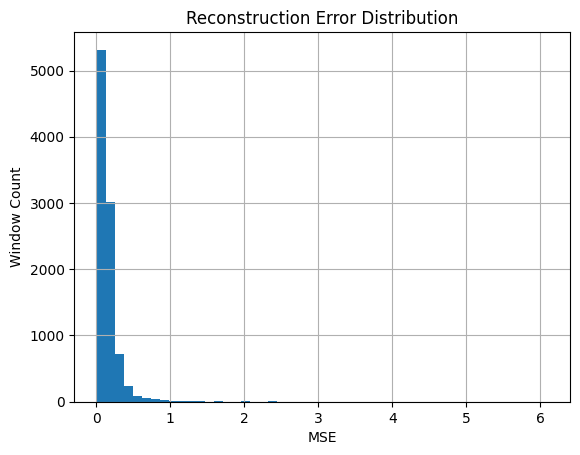

In [33]:
# reconstruct and compute error
X_hat = autoencoder.predict(X, batch_size=64)
recon_error = np.mean((X - X_hat)**2, axis=(1, 2))

plt.hist(recon_error, bins=50)
plt.title('Reconstruction Error Distribution')
plt.xlabel('MSE')
plt.ylabel('Window Count')
plt.grid(True)
plt.show()

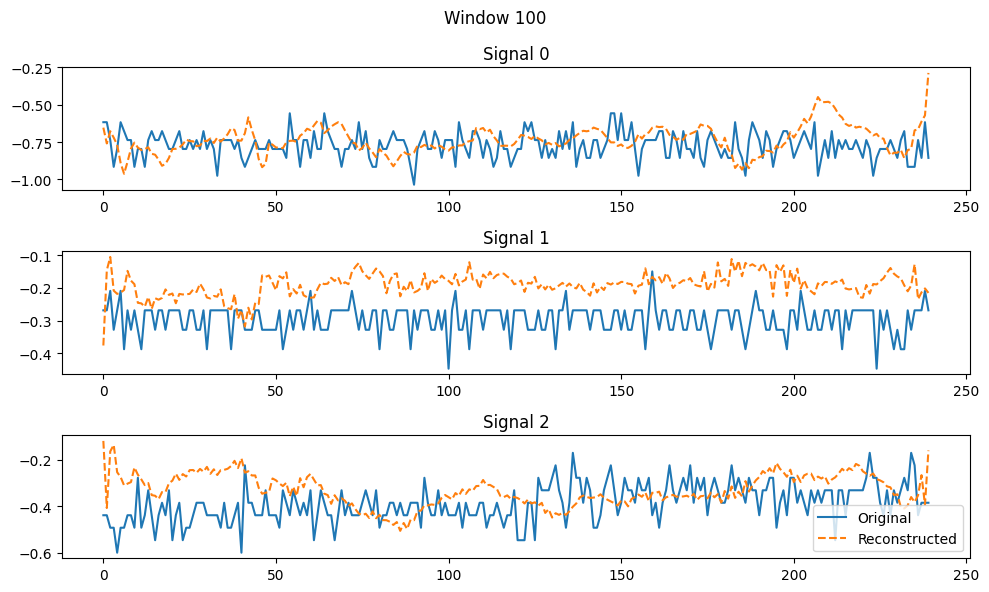

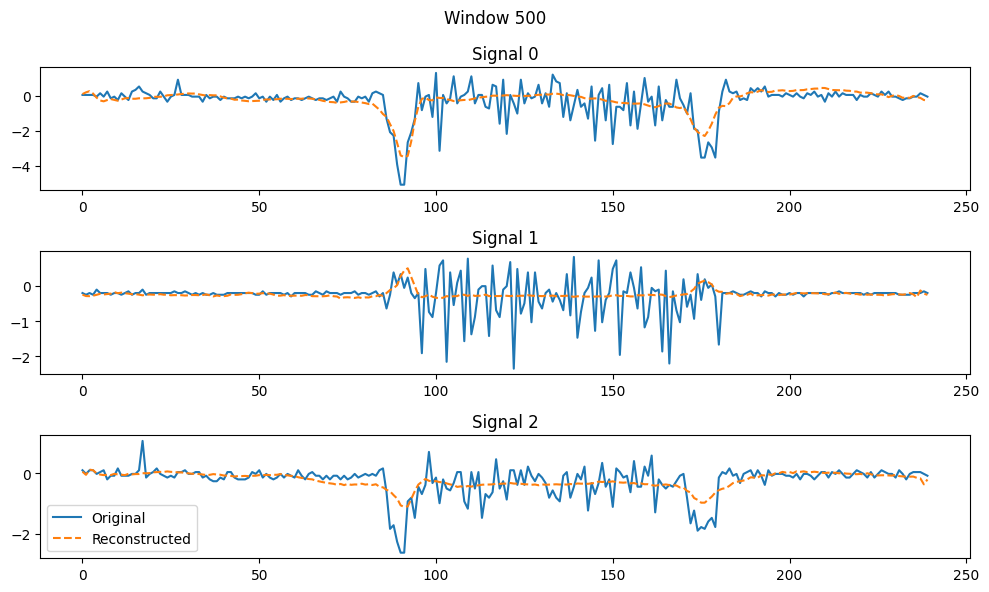

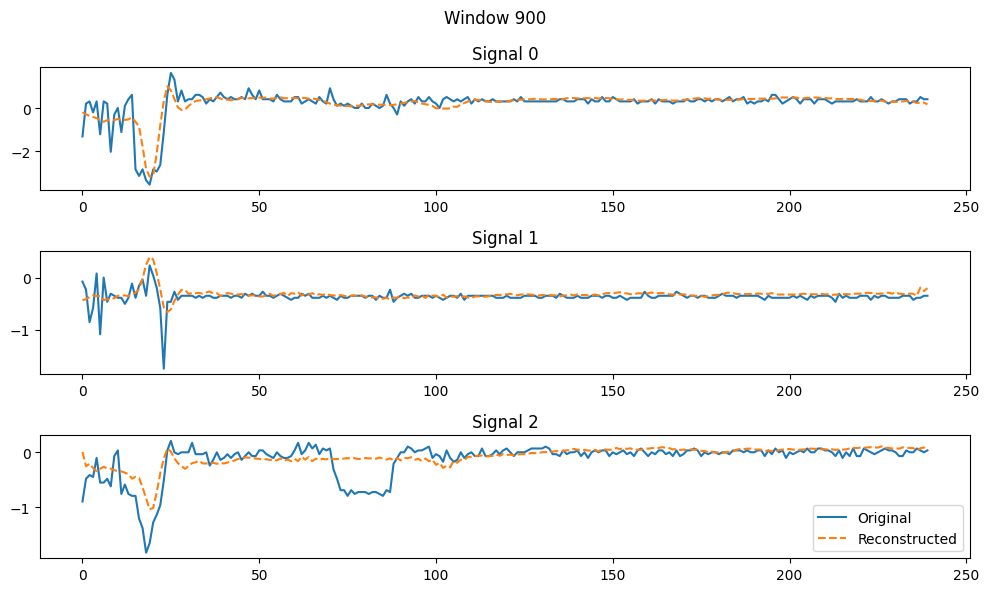

In [34]:
# visualize original vs reconstructed windows 
for i in [100, 500, 900]:
    fig, axs = plt.subplots(3, 1, figsize=(10, 6))
    for j in range(3): # 3 signals
        axs[j].plot(X[i, :, j], label='Original')
        axs[j].plot(X_hat[i, :, j], label='Reconstructed', linestyle='--')
        axs[j].set_title(f'Signal {j}')
    plt.suptitle(f'Window {i}')
    plt.legend()
    plt.tight_layout()
    plt.show()

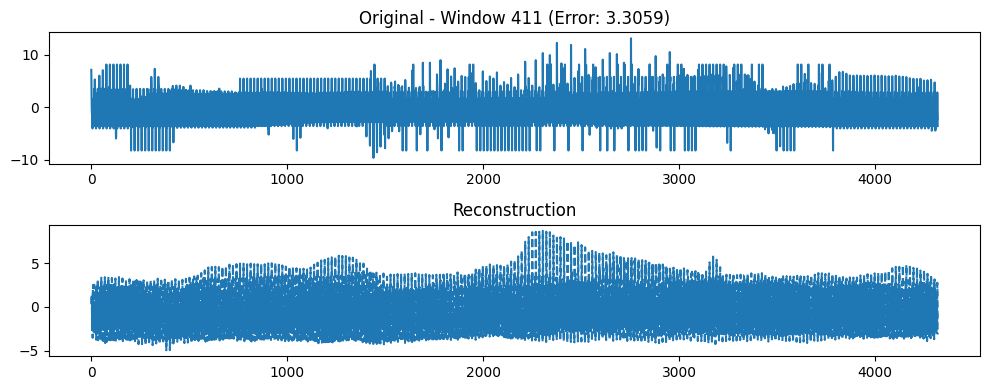

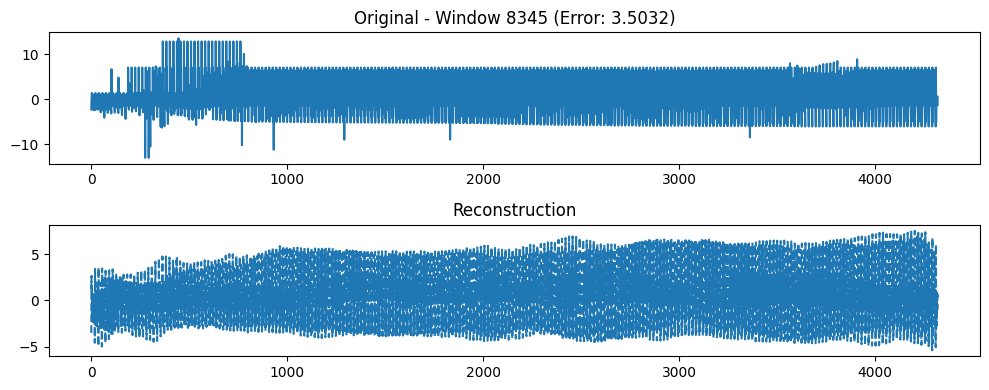

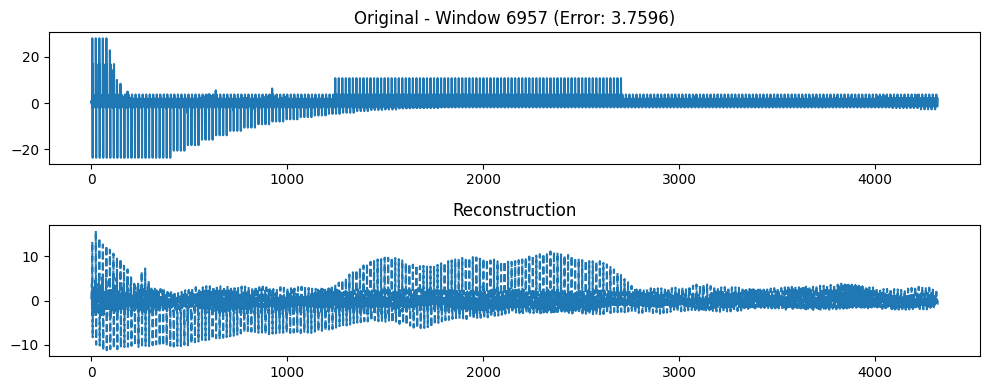

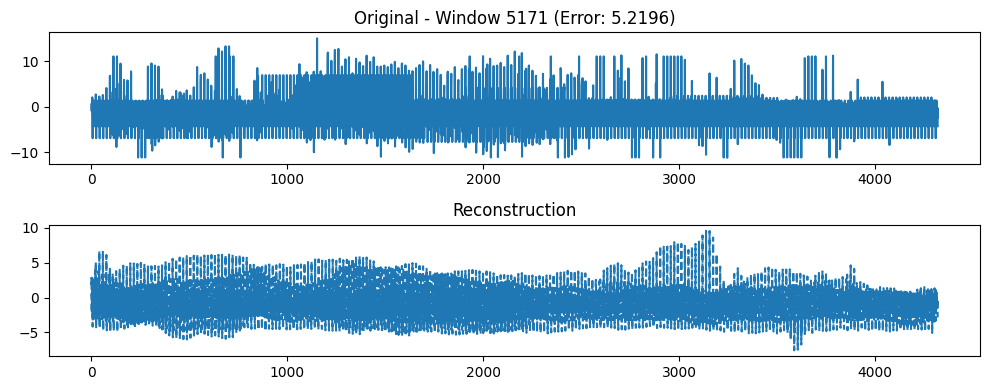

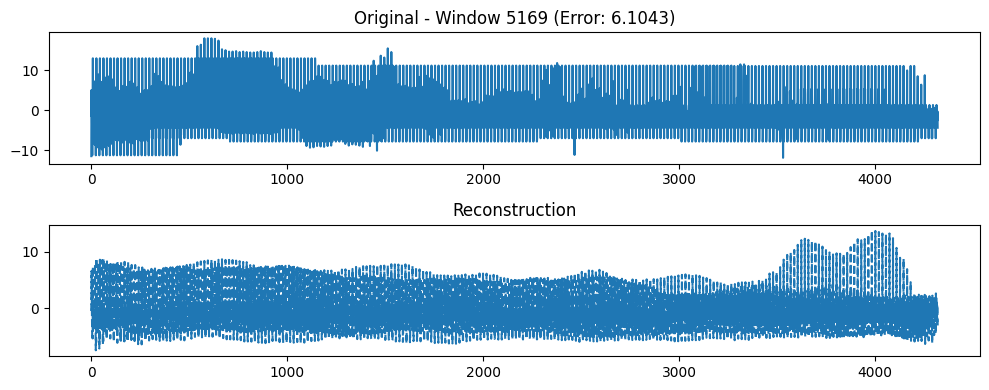

In [35]:
# show top-N anomalous windows
top_N = 5
idxs = np.argsort(recon_error)[-top_N:]

for i in idxs:
    fig, axs = plt.subplots(2, 1, figsize=(10, 4))
    axs[0].plot(X[i].flatten(), label='Original')
    axs[1].plot(X_hat[i].flatten(), label='Reconstructed', linestyle='--')
    axs[0].set_title(f'Original - Window {i} (Error: {recon_error[i]:.4f})')
    axs[1].set_title("Reconstruction")
    plt.tight_layout()
    plt.show()

In [36]:
# identify top 1% error windows
threshold = np.percentile(recon_error, 99)
top_error_idxs = np.where(recon_error > threshold)[0]

print(f"Top 1% anomaly threshold: {threshold:.4f}")
print(f"Number of windows above threshold: {len(top_error_idxs)}")

Top 1% anomaly threshold: 0.8837
Number of windows above threshold: 96
